# The Climate is Changing: How is the Research?

## Exploring Trends in Climate Articles: 2013 to 2023

#### This notebook builds explores Zipf's law in the corpus. It is currently a work in progress (May 2026).

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

In [2]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
        
# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [3]:
%%capture
%run notebooks/pos.ipynb

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [4]:
VOCAB = VOCAB.sort_values('n', ascending=False).reset_index()
VOCAB.index.name = 'term_rank' 
VOCAB = VOCAB.reset_index()
VOCAB = VOCAB.set_index('term_str')
VOCAB['term_rank'] = VOCAB['term_rank'] + 1
VOCAB[['term_rank','n','max_pos']].head()

,term_rank,n,max_pos
term_str,,,
the,1,14553,DT
the,2,11694,DT
and,3,8585,CC
of,4,8270,IN
of,5,7421,IN


In [7]:
VOCAB_2013 = VOCAB[VOCAB['year'] == '2013']
VOCAB_2018 = VOCAB[VOCAB['year'] == '2018']
VOCAB_2023 = VOCAB[VOCAB['year'] == '2023']

years = ['2013', '2018', '2023']

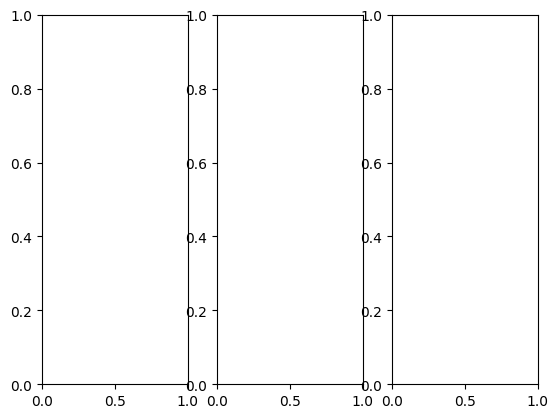

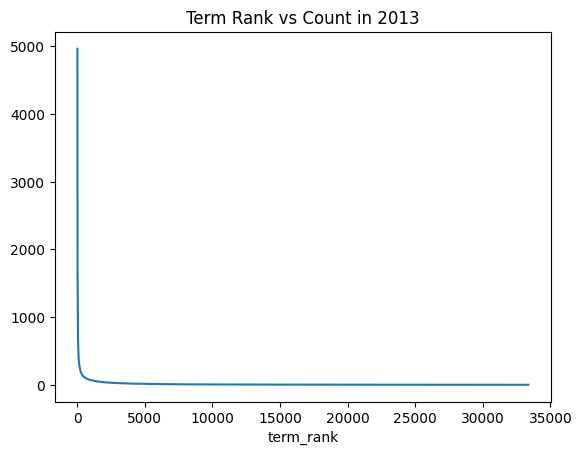

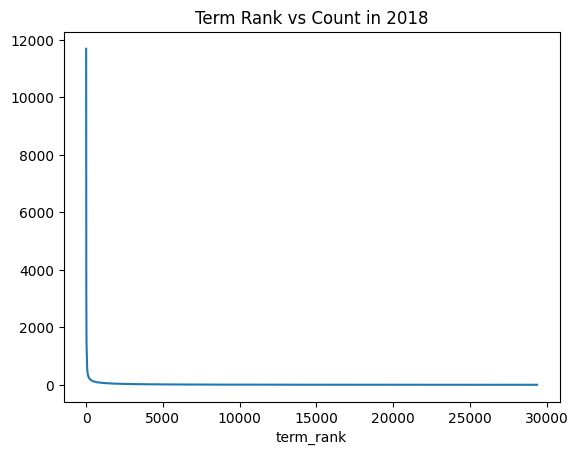

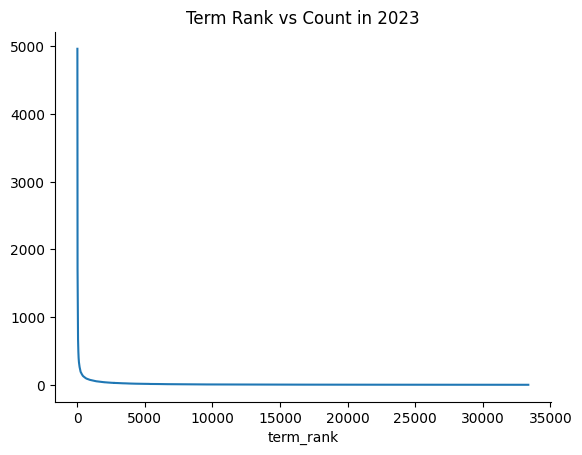

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3)
ax1 = VOCAB_2013.plot('term_rank', 'n', title=f"Term Rank vs Count in 2013", legend=False)
ax2 = VOCAB_2018.plot('term_rank', 'n', title=f"Term Rank vs Count in 2018", legend=False)
ax3 = VOCAB_2013.plot('term_rank', 'n', title=f"Term Rank vs Count in 2023", legend=False)
sns.despine()
plt.show()

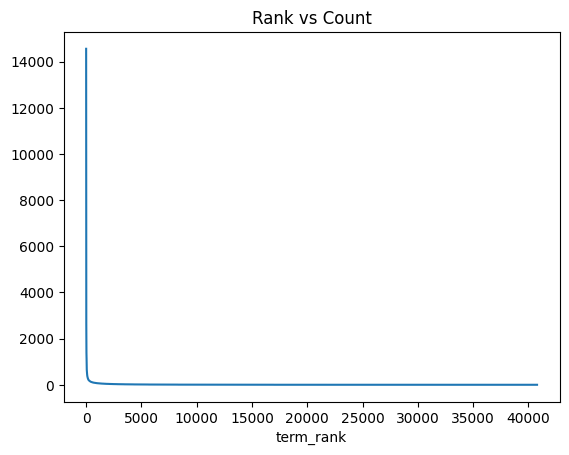

In [5]:
VOCAB.plot('term_rank', 'n', title="Rank vs Count", legend=False)
plt.show()